# Avaliação de Desempenho: Poda Estruturada de Camadas (*Layer Pruning*) no AnyGraph

Este notebook avalia o impacto da **Poda Estruturada de Camadas (*Layer Pruning*)** baseada no **Block Influence (BI)** nos modelos pré-treinados do AnyGraph (`pretrain_link1` e `pretrain_link2`), comparando o desempenho do modelo original com as versões reduzidas.

### Configurações Avaliadas:
1. **Modelo Inteiro (Baseline):** 8 camadas ativas por expert (0% de poda — 16.87M parâmetros).
2. **Poda Tier 1 (Conservadora):** Remoção das Camadas **`[5, 6]`** em todos os experts (**-25% de parâmetros** — 12.65M parâmetros).
3. **Poda Tier 2 (Agressiva):** Remoção das Camadas **`[4, 5, 6, 7]`** em todos os experts (**-50% de parâmetros** — 8.43M parâmetros).

### Datasets Oficiais Utilizados:
Utiliza os **5 datasets oficiais de classificação de nós do AnyGraph** (os mesmos do benchmark de *Global Magnitude Pruning*):
- **`arxiv`** (169.383 nós — artigos científicos)
- **`cora`** (25.191 nós — citações acadêmicas)
- **`home`** (9.795 nós — co-compra de produtos domésticos)
- **`pubmed`** (19.720 nós — publicações biomédicas)
- **`tech`** (47.431 nós — co-compra de tecnologia)

In [9]:
import os
import sys
import copy
import torch as t
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Identifica o diretorio AnyGraph de forma portavel
cwd = os.getcwd()
if os.path.basename(cwd) == "AnyGraph":
    PROJECT_ROOT = cwd
elif os.path.exists(os.path.join(cwd, "AnyGraph")):
    PROJECT_ROOT = os.path.join(cwd, "AnyGraph")
else:
    PROJECT_ROOT = os.path.abspath(".")

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
sys.argv = ["pruning_evaluation"]

from node_classification.params import args

# Usa GPU para velocidade máxima de avaliação
if t.cuda.is_available():
    args.gpu = "0"
    args.devices = ["cuda:0", "cuda:0"]
    print(f"Utilizando Dispositivo: {args.devices[0]} (GPU)")
else:
    args.gpu = "-1"
    args.devices = ["cpu", "cpu"]
    print("Utilizando Dispositivo: CPU")

args.tst_mode = "tst"
args.trn_mode = "train-all"
args.shot = 0
args.proj_method = "both"
args.gnn_layer = 3
args.latdim = 512

from node_classification.data_handler import MultiDataHandler
from node_classification.main import Exp
from Pruning_Methods.layer_pruner import BlockInfluenceLayerPruner

# Diretorios de saida
OUT_DIR = os.path.join(os.path.abspath(".."), "Block_Influence_results", "layer_pruning_evaluation")
os.makedirs(OUT_DIR, exist_ok=True)

# Datasets oficiais do benchmark
OFFICIAL_NODE_DATASETS = ["cora", "arxiv", "pubmed", "home", "tech"]
print(f"Datasets Oficiais de Avaliação: {OFFICIAL_NODE_DATASETS}")
print(f"Diretório de Resultados: {OUT_DIR}")

Utilizando Dispositivo: cuda:0 (GPU)
Datasets Oficiais de Avaliação: ['cora', 'arxiv', 'pubmed', 'home', 'tech']
Diretório de Resultados: /home/isabelly/Documentos/Graph_Pruning/Block_Influence_results/layer_pruning_evaluation


## 1. Pipeline Automatizado de Poda e Avaliação de Desempenho

In [10]:
def run_layer_pruning_experiment(model_checkpoint="pretrain_link1", datasets=OFFICIAL_NODE_DATASETS, repeat_times=1):
    """
    Executa a poda estruturada de camadas e avalia o desempenho em classificacao de nos.
    Compara:
      1. Modelo Inteiro (Baseline - 8 camadas)
      2. Poda Tier 1 (Sem camadas [5, 6] -> 6 camadas, -25% params)
      3. Poda Tier 2 (Sem camadas [4, 5, 6, 7] -> 4 camadas, -50% params)
    """
    print("=" * 80)
    print(f"EXPERIMENTO DE PODA DE CAMADAS (LAYER PRUNING) - CHECKPOINT: {model_checkpoint}")
    print(f"Datasets Oficiais AnyGraph: {datasets}")
    print("=" * 80)
    
    args.load_model = model_checkpoint
    handler = MultiDataHandler(datasets, [datasets])
    exp = Exp(handler)
    exp.prepare_model()
    
    results = []
    
    # -------------------------------------------------------------
    # 1. Baseline: Modelo Inteiro (8 camadas, 0% poda)
    # -------------------------------------------------------------
    print("\n[1/3] Avaliando Modelo Inteiro (Baseline - 8 camadas ativas)...")
    exp.load_model(model_checkpoint)
    df_base = exp.evaluate(repeat_times=repeat_times)
    for _, row in df_base.iterrows():
        results.append({
            "Configuração": "Modelo Inteiro (Baseline)",
            "Camadas Removidas": "Nenhuma (8 camadas)",
            "Camadas Restantes": 8,
            "Redução Parâmetros (%)": "0.0%",
            "Dataset": row["Dataset"],
            "Acurácia": row["Acc_mean"],
            "F1-Score": row["F1_mean"]
        })
        
    # -------------------------------------------------------------
    # 2. Poda Tier 1: Remoção das Camadas [5, 6] (6 camadas, 25% poda)
    # -------------------------------------------------------------
    print("\n[2/3] Avaliando Poda Tier 1: Removendo Camadas [5, 6] (-25% parâmetros)...")
    exp.load_model(model_checkpoint)  # Recarrega modelo original
    pruner_t1 = BlockInfluenceLayerPruner(exp.model)
    pruned_model_t1 = pruner_t1.prune_specific_layers({i: [5, 6] for i in range(len(exp.model.experts))})
    exp.model = pruned_model_t1
    
    df_t1 = exp.evaluate(repeat_times=repeat_times)
    for _, row in df_t1.iterrows():
        results.append({
            "Configuração": "Poda Tier 1 (Sem [5, 6])",
            "Camadas Removidas": "[5, 6]",
            "Camadas Restantes": 6,
            "Redução Parâmetros (%)": "25.0%",
            "Dataset": row["Dataset"],
            "Acurácia": row["Acc_mean"],
            "F1-Score": row["F1_mean"]
        })
        
    # -------------------------------------------------------------
    # 3. Poda Tier 2: Remoção das Camadas [4, 5, 6, 7] (4 camadas, 50% poda)
    # -------------------------------------------------------------
    print("\n[3/3] Avaliando Poda Tier 2: Removendo Camadas [4, 5, 6, 7] (-50% parâmetros)...")
    exp.load_model(model_checkpoint)  # Recarrega modelo original
    pruner_t2 = BlockInfluenceLayerPruner(exp.model)
    pruned_model_t2 = pruner_t2.prune_specific_layers({i: [4, 5, 6, 7] for i in range(len(exp.model.experts))})
    exp.model = pruned_model_t2
    
    df_t2 = exp.evaluate(repeat_times=repeat_times)
    for _, row in df_t2.iterrows():
        results.append({
            "Configuração": "Poda Tier 2 (Sem [4, 5, 6, 7])",
            "Camadas Removidas": "[4, 5, 6, 7]",
            "Camadas Restantes": 4,
            "Redução Parâmetros (%)": "50.0%",
            "Dataset": row["Dataset"],
            "Acurácia": row["Acc_mean"],
            "F1-Score": row["F1_mean"]
        })
        
    df_results = pd.DataFrame(results)
    
    # Salva CSVs de resultados
    csv_path = os.path.join(OUT_DIR, f"desempenho_poda_camadas_{model_checkpoint}.csv")
    df_results.to_csv(csv_path, index=False)
    print(f"Resultados salvos em: {csv_path}")
    
    # -------------------------------------------------------------
    # Gráfico Comparativo de Desempenho
    # -------------------------------------------------------------
    datasets_plot = [d for d in df_results["Dataset"].unique() if d != "OVERALL"] + ["OVERALL"]
    configs = ["Modelo Inteiro (Baseline)", "Poda Tier 1 (Sem [5, 6])", "Poda Tier 2 (Sem [4, 5, 6, 7])"]
    
    fig, (ax_acc, ax_f1) = plt.subplots(1, 2, figsize=(16, 5))
    
    x = np.arange(len(datasets_plot))
    width = 0.26
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    
    for idx, cfg in enumerate(configs):
        sub_df = df_results[df_results["Configuração"] == cfg]
        acc_vals = [sub_df[sub_df["Dataset"] == d]["Acurácia"].values[0] for d in datasets_plot]
        f1_vals = [sub_df[sub_df["Dataset"] == d]["F1-Score"].values[0] for d in datasets_plot]
        
        ax_acc.bar(x + idx * width - width, acc_vals, width, label=cfg, color=colors[idx], edgecolor="black")
        ax_f1.bar(x + idx * width - width, f1_vals, width, label=cfg, color=colors[idx], edgecolor="black")
        
    ax_acc.set_title(f"Acurácia por Dataset ({model_checkpoint})", fontsize=12, fontweight="bold", pad=10)
    ax_acc.set_ylabel("Acurácia (Acc)", fontsize=11)
    ax_acc.set_xticks(x)
    ax_acc.set_xticklabels([d.upper() for d in datasets_plot], fontsize=11, fontweight="bold")
    ax_acc.grid(True, alpha=0.3, axis="y")
    ax_acc.legend(fontsize=9, loc="lower right")
    
    ax_f1.set_title(f"Macro F1-Score por Dataset ({model_checkpoint})", fontsize=12, fontweight="bold", pad=10)
    ax_f1.set_ylabel("Macro F1", fontsize=11)
    ax_f1.set_xticks(x)
    ax_f1.set_xticklabels([d.upper() for d in datasets_plot], fontsize=11, fontweight="bold")
    ax_f1.grid(True, alpha=0.3, axis="y")
    ax_f1.legend(fontsize=9, loc="lower right")
    
    plt.tight_layout()
    plot_path = os.path.join(OUT_DIR, f"grafico_desempenho_poda_camadas_{model_checkpoint}.png")
    plt.savefig(plot_path, dpi=300)
    print(f"Gráfico salvo em: {plot_path}")
    plt.show()
    
    return df_results

## 2. Avaliação de Poda de Camadas no Modelo 1 (`pretrain_link1`)

EXPERIMENTO DE PODA DE CAMADAS (LAYER PRUNING) - CHECKPOINT: pretrain_link1
Datasets Oficiais AnyGraph: ['cora', 'arxiv', 'pubmed', 'home', 'tech']
2026-08-28 15:08:50.360809: Loading dataset arxiv
Dataset: arxiv, Node num: 169383, Edge num: 1456326
2026-08-28 15:08:55.334495: Loading dataset cora
Dataset: cora, Node num: 25191, Edge num: 121912


/home/isabelly/Documentos/Graph_Pruning/AnyGraph/node_classification/data_handler.py:94: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(degree, -0.5), [-1])


2026-08-28 15:08:55.776179: Loading dataset home
Dataset: home, Node num: 9795, Edge num: 149463
2026-08-28 15:08:56.037204: Loading dataset pubmed
Dataset: pubmed, Node num: 19720, Edge num: 124138
2026-08-28 15:08:56.344690: Loading dataset tech
Dataset: tech, Node num: 47431, Edge num: 2162611
['arxiv', 'cora', 'home', 'pubmed', 'tech']
Test group 0 ['arxiv', 'cora', 'home', 'pubmed', 'tech']
Total params: 16.87552
Trainable params: 16.87552
Non-trainable params: 0.0

[1/3] Avaliando Modelo Inteiro (Baseline - 8 camadas ativas)...
2026-08-28 15:09:13.026858: Loaded pretrain_link1
2026-08-28 15:09:18.568523: Epoch 100/100, arxiv Test: Acc_mean = 0.5134, Acc_std = 0.0000, F1_mean = 0.2953, F1_std = 0.0000, tstNum_mean = 48603.0000, tstNum_std = 0.0000      
2026-08-28 15:09:19.303142: Epoch 100/100, cora Test: Acc_mean = 0.6298, Acc_std = 0.0000, F1_mean = 0.5712, F1_std = 0.0000, tstNum_mean = 3414.0000, tstNum_std = 0.0000      
2026-08-28 15:09:19.683910: Epoch 100/100, home Test: 

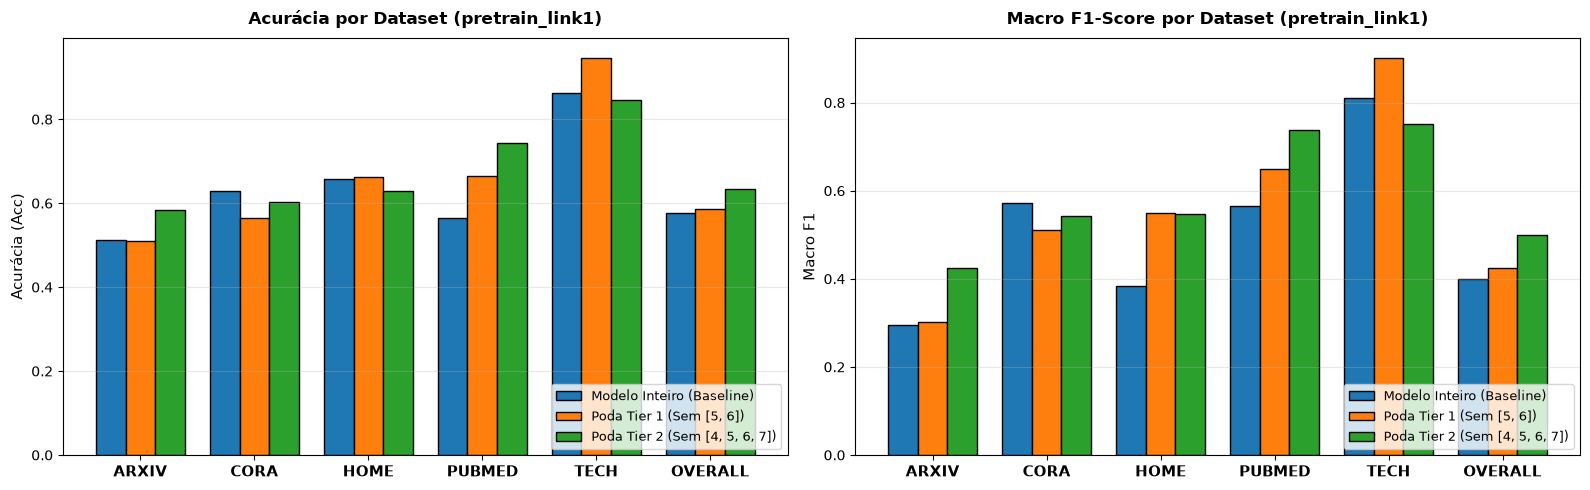

=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 1 ===


,Configuração,Camadas Removidas,Camadas Restantes,Redução Parâmetros (%),Dataset,Acurácia,F1-Score
0,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,arxiv,0.513384,0.295256
1,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,cora,0.629760,0.571204
2,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,home,0.658325,0.384707
3,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,pubmed,0.564148,0.564850
4,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,tech,0.861902,0.810167
5,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,OVERALL,0.575506,0.400069
6,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,arxiv,0.509516,0.301113
7,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,cora,0.564148,0.509997
8,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,home,0.661900,0.548623
9,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,pubmed,0.664300,0.650384


In [11]:
df_res1 = run_layer_pruning_experiment("pretrain_link1", OFFICIAL_NODE_DATASETS, repeat_times=1)
print("=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 1 ===")
display(df_res1)

## 3. Avaliação de Poda de Camadas no Modelo 2 (`pretrain_link2`)

EXPERIMENTO DE PODA DE CAMADAS (LAYER PRUNING) - CHECKPOINT: pretrain_link2
Datasets Oficiais AnyGraph: ['cora', 'arxiv', 'pubmed', 'home', 'tech']
2026-08-28 15:09:54.295437: Loading dataset arxiv
Dataset: arxiv, Node num: 169383, Edge num: 1456326
2026-08-28 15:09:58.625995: Loading dataset cora
Dataset: cora, Node num: 25191, Edge num: 121912


/home/isabelly/Documentos/Graph_Pruning/AnyGraph/node_classification/data_handler.py:94: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.reshape(np.power(degree, -0.5), [-1])


2026-08-28 15:09:59.076380: Loading dataset home
Dataset: home, Node num: 9795, Edge num: 149463
2026-08-28 15:09:59.344256: Loading dataset pubmed
Dataset: pubmed, Node num: 19720, Edge num: 124138
2026-08-28 15:09:59.676846: Loading dataset tech
Dataset: tech, Node num: 47431, Edge num: 2162611
['arxiv', 'cora', 'home', 'pubmed', 'tech']
Test group 0 ['arxiv', 'cora', 'home', 'pubmed', 'tech']
Total params: 16.87552
Trainable params: 16.87552
Non-trainable params: 0.0

[1/3] Avaliando Modelo Inteiro (Baseline - 8 camadas ativas)...
2026-08-28 15:10:05.029899: Loaded pretrain_link2
2026-08-28 15:10:09.671019: Epoch 100/100, arxiv Test: Acc_mean = 0.6310, Acc_std = 0.0000, F1_mean = 0.3767, F1_std = 0.0000, tstNum_mean = 48603.0000, tstNum_std = 0.0000      
2026-08-28 15:10:10.334516: Epoch 100/100, cora Test: Acc_mean = 0.6221, Acc_std = 0.0000, F1_mean = 0.5569, F1_std = 0.0000, tstNum_mean = 3414.0000, tstNum_std = 0.0000      
2026-08-28 15:10:10.700935: Epoch 100/100, home Test: 

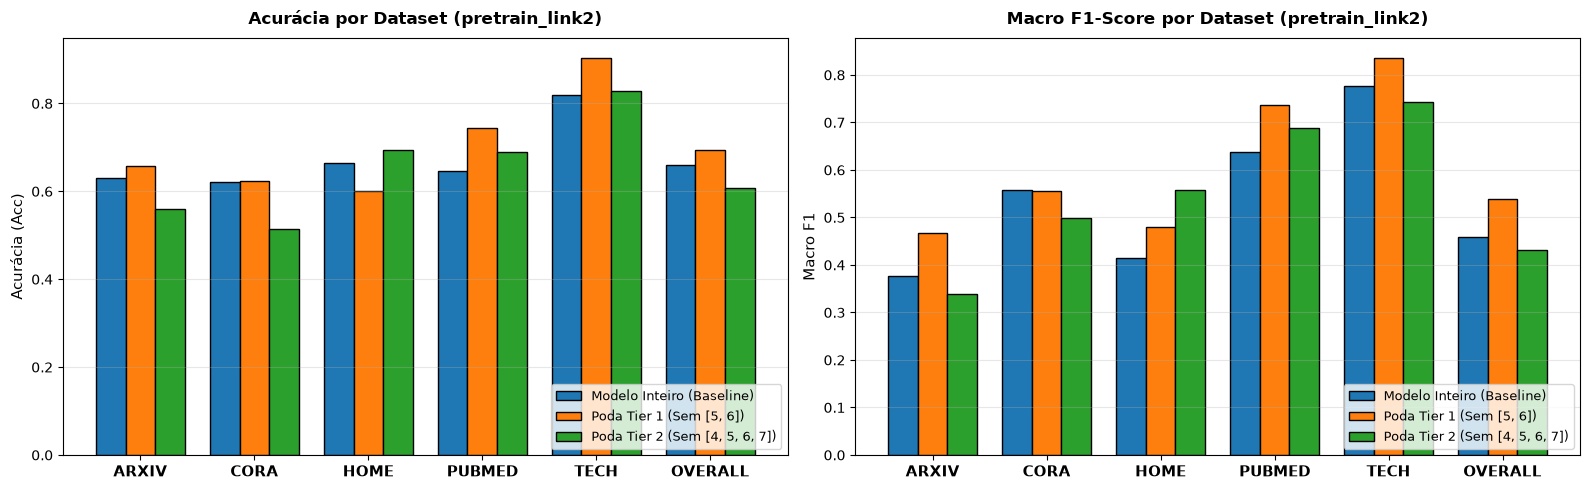

=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 2 ===


,Configuração,Camadas Removidas,Camadas Restantes,Redução Parâmetros (%),Dataset,Acurácia,F1-Score
0,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,arxiv,0.631031,0.376675
1,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,cora,0.622144,0.556939
2,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,home,0.663432,0.414893
3,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,pubmed,0.646552,0.637781
4,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,tech,0.819840,0.777146
5,Modelo Inteiro (Baseline),Nenhuma (8 camadas),8,0.0%,OVERALL,0.659002,0.458552
6,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,arxiv,0.657593,0.466664
7,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,cora,0.623023,0.556603
8,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,home,0.601124,0.480155
9,"Poda Tier 1 (Sem [5, 6])","[5, 6]",6,25.0%,pubmed,0.743915,0.737215


In [12]:
df_res2 = run_layer_pruning_experiment("pretrain_link2", OFFICIAL_NODE_DATASETS, repeat_times=1)
print("=== TABELA CONSOLIDADA DE DESEMPENHO - MODELO 2 ===")
display(df_res2)